# Customer Churn Hive ETL
Notebook này dùng để kết nối Hive, chạy DDL/DML cho tầng raw và curated, và kiểm tra output churn analytics.

## 1. Cài thư viện trong notebook
Chạy cell cài package trước khi import. Bạn có thể chỉnh package theo cách kết nối Hive bạn chọn.

In [312]:
# Uncomment when ready to install libraries in the notebook ke rnel
%pip install pyhive thrift thrift-sasl pandas sqlalchemy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 3.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 26.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 36.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 40.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 25.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Cấu hình kết nối Hive

In [286]:
from sqlalchemy import create_engine, text
import pandas as pd

class HiveClient:
    def __init__(self, connection_string = ''):
        self.engine = create_engine(connection_string)
        print(self.engine)
        
    def get_engine(self):
        return self.engine
        
    def ping(self):
        df = pd.read_sql("SHOW DATABASES", self.engine)
        print(df.head())
    
    def execute(self, query: str):
        with self.engine.connect() as conn:
            conn.execute(text(query))      
            
    def query(self, query: str) -> pd.DataFrame:
        with self.engine.connect() as conn:
            conn.execute(text("SET hive.execution.engine=tez"))
            # conn.execute(text("SET hive.exec.dynamic.partition=true"))
            # conn.execute(text("SET hive.exec.dynamic.partition.mode=nonstrict"))
            # conn.execute(text("SET hive.auto.convert.join=false"))
            # conn.execute(text("SET hive.exec.max.dynamic.partitions=100000"))
            # conn.execute(text("SET hive.exec.max.dynamic.partitions.pernode=10000"))
            conn.execute(text("SET hive.stats.autogather=false"))          
            conn.execute(text("SET hive.auto.convert.join=false"))
            conn.execute(text("SET hive.exec.dynamic.partition=true"))
            conn.execute(text("SET hive.exec.dynamic.partition.mode=nonstrict"))

            # conn.execute(text("SET hive.cbo.enable=false"))                 # disable cost-based optimizer
            # conn.execute(text("SET hive.stats.column.autogather=false"))
            # conn.execute(text("SET hive.vectorized.execution.enabled=false"))
            return pd.read_sql(query, conn)

In [287]:
hive_client = HiveClient('hive://root@dtwarehouse-hiveserver2:10000')
hive_client.ping()

Engine(hive://root@dtwarehouse-hiveserver2:10000)
  database_name
0       default
1     raw_churn


In [257]:
raw_ddl = '''CREATE DATABASE IF NOT EXISTS raw_churn'''
create_table_raw_churn_customers_raw = '''
CREATE EXTERNAL TABLE IF NOT EXISTS raw_churn.customers_raw (
  customer_id STRING,
  signup_date DATE,
  birth_year INT,
  gender STRING,
  city STRING,
  acquisition_channel STRING,
  segment STRING,
  is_active BOOLEAN
)
PARTITIONED BY (dt STRING)
STORED AS PARQUET
LOCATION 'hdfs://namenode:8020/data/raw/churn/customers'
'''
create_table_raw_churn_orders_raw = '''
CREATE EXTERNAL TABLE IF NOT EXISTS raw_churn.orders_raw (
  order_id STRING,
  customer_id STRING,
  order_ts TIMESTAMP,
  order_status STRING,
  currency STRING,
  subtotal_amount DECIMAL(18,2),
  discount_amount DECIMAL(18,2),
  shipping_fee DECIMAL(18,2),
  tax_amount DECIMAL(18,2),
  total_amount DECIMAL(18,2),
  payment_method STRING,
  promo_code STRING
)
PARTITIONED BY (dt STRING)
STORED AS PARQUET
LOCATION 'hdfs://namenode:8020/data/raw/churn/orders'
'''


In [275]:
hive_client.execute(raw_ddl)
hive_client.execute(create_table_raw_churn_customers_raw)
hive_client.execute(create_table_raw_churn_orders_raw)
hive_client.execute("MSCK REPAIR TABLE raw_churn.customers_raw")
hive_client.execute("MSCK REPAIR TABLE raw_churn.orders_raw")

In [288]:
customer_fs = pd.read_sql(
    "SELECT * FROM raw_churn.customers_raw LIMIT 100",
    hive_client.get_engine()
)
customer_fs

,customer_id,signup_date,birth_year,gender,city,acquisition_channel,segment,is_active,dt
0,CUST_000001,2026-03-16,1985.0,female,Ha Noi,ads,regular,True,2026-04-11
1,CUST_000002,2026-01-11,1972.0,male,Ho Chi Minh,organic,vip,True,2026-04-11
2,CUST_000003,2024-09-13,2004.0,unknown,Ha Noi,social,regular,True,2026-04-11
3,CUST_000004,2026-04-04,1980.0,unknown,Da Nang,referral,regular,True,2026-04-11
4,CUST_000005,2025-05-01,1994.0,male,Da Nang,referral,vip,True,2026-04-11
...,...,...,...,...,...,...,...,...,...
95,CUST_000096,2025-06-16,NaN,other,Nha Trang,referral,regular,True,2026-04-11
96,CUST_000097,2024-05-07,1986.0,female,Can Tho,ads,regular,True,2026-04-11
97,CUST_000098,2025-07-12,1974.0,male,Ha Noi,referral,regular,True,2026-04-11
98,CUST_000099,2025-06-19,1999.0,other,Nha Trang,social,regular,False,2026-04-11


In [289]:
order_df = pd.read_sql(
    "SELECT * FROM raw_churn.orders_raw LIMIT 100",
    hive_client.get_engine()
)
order_df

,order_id,customer_id,order_ts,order_status,currency,subtotal_amount,discount_amount,shipping_fee,tax_amount,total_amount,payment_method,promo_code,dt
0,ORD_20251212_00000003,CUST_000648,2025-12-12 18:45:17.924192,completed,VND,158974.0,0.00,15000.0,12717.92,186691.92,ewallet,NaN,2025-12-12
1,ORD_20251212_00000127,CUST_000432,2025-12-12 09:36:41.924192,completed,VND,246817.0,0.00,25000.0,19745.36,291562.36,bank_transfer,VIP30,2025-12-12
2,ORD_20251212_00000437,CUST_000166,2025-12-12 13:08:32.924192,completed,VND,570282.0,0.00,25000.0,45622.56,640904.56,bank_transfer,NaN,2025-12-12
3,ORD_20251212_00000442,CUST_000508,2025-12-12 16:37:47.924192,completed,VND,985045.0,0.00,15000.0,78803.60,1078848.60,bank_transfer,NaN,2025-12-12
4,ORD_20251212_00000663,CUST_000250,2025-12-12 23:26:30.924192,completed,VND,1161987.0,0.00,25000.0,92958.96,1279945.96,card,VIP30,2025-12-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ORD_20251214_00002545,CUST_000086,2025-12-14 20:40:30.924192,completed,VND,366929.0,55039.35,25000.0,24951.17,361840.82,cod,NaN,2025-12-14
96,ORD_20251214_00002574,CUST_000741,2025-12-14 13:07:53.924192,completed,VND,550739.0,55073.90,0.0,39653.21,535318.31,card,LOYAL20,2025-12-14
97,ORD_20251214_00002899,CUST_000897,2025-12-14 00:30:51.924192,completed,VND,264384.0,0.00,0.0,21150.72,285534.72,ewallet,LOYAL20,2025-12-14
98,ORD_20251214_00002946,CUST_000117,2025-12-14 16:45:42.924192,completed,VND,152967.0,0.00,15000.0,12237.36,180204.36,bank_transfer,NaN,2025-12-14


In [308]:
sql_1 = '''
SELECT *
FROM raw_churn.orders_raw
'''
sql_1_df = pd.read_sql(sql_1,hive_client.get_engine())

In [309]:
sql_1_df

,order_id,customer_id,order_ts,order_status,currency,subtotal_amount,discount_amount,shipping_fee,tax_amount,total_amount,payment_method,promo_code,dt
0,ORD_20251212_00000003,CUST_000648,2025-12-12 18:45:17.924192,completed,VND,158974.0,0.00,15000.0,12717.92,186691.92,ewallet,NaN,2025-12-12
1,ORD_20251212_00000127,CUST_000432,2025-12-12 09:36:41.924192,completed,VND,246817.0,0.00,25000.0,19745.36,291562.36,bank_transfer,VIP30,2025-12-12
2,ORD_20251212_00000437,CUST_000166,2025-12-12 13:08:32.924192,completed,VND,570282.0,0.00,25000.0,45622.56,640904.56,bank_transfer,NaN,2025-12-12
3,ORD_20251212_00000442,CUST_000508,2025-12-12 16:37:47.924192,completed,VND,985045.0,0.00,15000.0,78803.60,1078848.60,bank_transfer,NaN,2025-12-12
4,ORD_20251212_00000663,CUST_000250,2025-12-12 23:26:30.924192,completed,VND,1161987.0,0.00,25000.0,92958.96,1279945.96,card,VIP30,2025-12-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16136,ORD_20260416_00069722,CUST_005888,2026-04-16 18:04:37.492155,cancelled,VND,573575.0,114715.00,30000.0,36708.80,525568.80,ewallet,NaN,2026-04-16
16137,ORD_20260416_00069723,CUST_006260,2026-04-16 18:04:44.492155,completed,VND,744667.0,111700.05,0.0,50637.36,683604.31,bank_transfer,NaN,2026-04-16
16138,ORD_20260416_00069732,CUST_012261,2026-04-16 18:08:30.492155,completed,VND,344522.0,17226.10,25000.0,26183.67,378479.57,card,NaN,2026-04-16
16139,ORD_20260416_00069733,CUST_020687,2026-04-16 18:04:39.492155,completed,VND,746732.0,0.00,15000.0,59738.56,821470.56,cod,NaN,2026-04-16


In [310]:
sql_1_df[[
    "subtotal_amount",
    "discount_amount",
    "shipping_fee",
    "tax_amount",
    "total_amount"
]].describe()

,subtotal_amount,discount_amount,shipping_fee,tax_amount,total_amount
count,1.614100e+04,16141.000000,16141.000000,16141.000000,1.614100e+04
mean,6.790855e+05,34541.032411,17464.531318,51563.556700,7.135725e+05
std,3.014306e+05,54799.278746,11566.602952,23275.232989,3.142872e+05
min,1.500740e+05,0.000000,0.000000,9671.230000,1.311854e+05
25%,4.185300e+05,0.000000,0.000000,31672.220000,4.483088e+05
50%,6.777860e+05,0.000000,25000.000000,50917.840000,7.030314e+05
75%,9.422580e+05,54047.350000,30000.000000,71272.480000,9.803064e+05
max,1.199954e+06,239900.000000,30000.000000,95996.320000,1.324116e+06


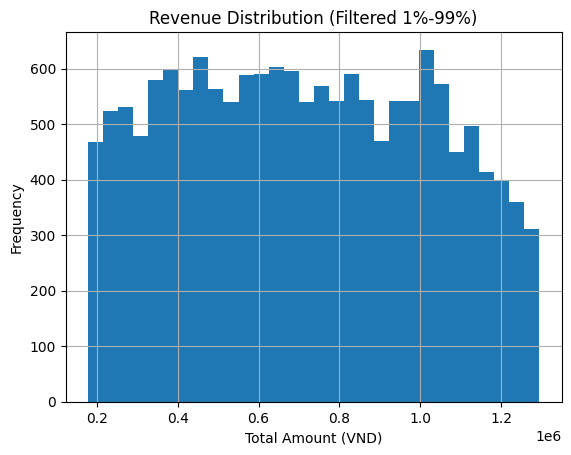

In [316]:
q_low = sql_1_df["total_amount"].quantile(0.01)
q_high = sql_1_df["total_amount"].quantile(0.99)

filtered = sql_1_df[
    (sql_1_df["total_amount"] >= q_low) &
    (sql_1_df["total_amount"] <= q_high)
]

plt.figure()
filtered["total_amount"].hist(bins=30)

plt.title("Revenue Distribution (Filtered 1%-99%)")
plt.xlabel("Total Amount (VND)")
plt.ylabel("Frequency")

plt.show()

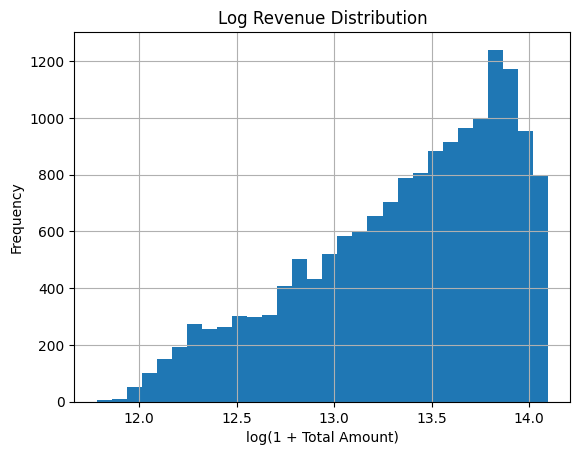

In [317]:
import numpy as np

plt.figure()
np.log1p(sql_1_df["total_amount"]).hist(bins=30)

plt.title("Log Revenue Distribution")
plt.xlabel("log(1 + Total Amount)")
plt.ylabel("Frequency")

plt.show()